# Estimating training time *before* you train — the AI Model Factory calibrator

**The problem.** On this repo's own hardware, the identical 40-epoch CIFAR-100 resnet18 run takes
**~2.1 min** on the dual RTX PRO 6000 workstation and **~10.6 min** on an RTX 2000 Ada laptop — a
6.7× gap — while the spec-sheet FLOPS ratio of those GPUs is an order of magnitude wider.  If a
planned configuration would take 2 days, we want to know **before** the run starts and redesign
(smaller model, fewer epochs, different hardware) instead of finding out on day 2.

Naive estimation fails because the *binding constraint* changes with the machine: at 32×32 the
workstation is **per-step-overhead-bound** (hundreds of kernel launches doing microseconds of math
each) while the power-capped laptop is genuinely **compute-bound**.  So this notebook estimates in
three tiers, each with an honest accuracy label:

| tier | needs | answers | accuracy |
|---|---|---|---|
| **0 — probe** (~3 min, once per machine+power-state) | the machine | its real ceilings: burst + *sustained* TFLOPS, memory BW, launch overhead | measured |
| **1 — analytical roofline** | only a probe vector (or spec numbers) | "2 minutes or 2 hours or 2 days?" — the **redesign gate** | order of magnitude |
| **2 — calibration** (~2.5 min on the target) | the target machine | wall-clock prediction | ~5–10% (±10–15% on power-capped laptops) |

Published cross-GPU predictors (Paleo ICLR'17, Habitat ATC'21 at 11.8% mean error, DNNPerf) top out
around 10–15% error; nothing reliably beats ~5% without running on the exact target — these bands
are honest, not conservative.  Every run appends a JSON record to `results/`, so the more machines
run this notebook, the better cross-machine estimates get.

**Usage:** pick the workload in §3, plug the laptop in (power state is recorded — battery runs are
kept separate), and **Run All** (~6 min on a GPU).

In [1]:
# -- Setup: paths, device, and the SAME backend flags as the training notebook --------------------
# The calibration must run under the exact torch.backends state of the run it predicts:
# cifar100_hf_train.ipynb calls set_seed(42) THEN enable_fast_matmul(), which lands on
# cudnn deterministic=True + benchmark=True + TF32 on.  Different flags = different kernel
# selection = a different program being timed.
import os, sys, time, statistics

for rel in ('../common', '../a1-cv', '../a1-imagenet32'):
    p = os.path.normpath(os.path.join(os.getcwd(), rel))
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

import torch
from gpu_check import get_device, set_seed
DEVICE = get_device()
set_seed(42)
try:
    from gpu_check import enable_fast_matmul
    enable_fast_matmul()
except Exception:
    pass

import perfkit as pk
print('\nbackend flags:', pk.snapshot_backend_flags())

  PyTorch  : 2.11.0+cu128
  CUDA     : 12.8
  Device   : cuda  [1 GPU visible - CUDA_VISIBLE_DEVICES='GPU-c9c8e67d-cae5-8bef-2e72-629c9cd326ea']
    cuda:0  NVIDIA RTX 2000 Ada Generation Laptop GPU  sm_89  8.6 GB  <- cuda:0 (primary)

backend flags: {'float32_matmul_precision': 'high', 'cudnn_benchmark': True, 'cudnn_deterministic': True, 'matmul_tf32': True, 'cudnn_tf32': True}


## 1. Machine fingerprint

Who is this machine, exactly?  **Power state is part of the identity on purpose**: the same laptop
on battery vs AC runs a different P-state, power cap, and boost policy — its throughput can differ
2× — so records are tagged `ac`/`batt` and never mixed.  The Windows power plan, GPU power limits
(default *and* max boost), and the torch backend-flag snapshot all ride along, because each one
silently changes measured speed.

In [2]:
FP = pk.fingerprint(DEVICE)
for k, v in FP.items():
    if k != 'backend_flags':
        print(f'{k:22s} {v}')
if FP.get('power_plugged') is False:
    print('\n*** WARNING: running on BATTERY -- results will NOT match plugged-in training runs.')
    print('*** Plug in and re-run from the top before trusting or saving these numbers.')

hostname               Mushu
os                     Windows 11
python                 3.12.13
torch                  2.11.0+cu128
device_type            cuda
cpu                    Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
cpu_cores_logical      20
ram_gb                 63.8
cpu_cores_physical     14
power_plugged          True
battery_percent        100
power_plan             Balanced
gpu                    NVIDIA RTX 2000 Ada Generation Laptop GPU
gpu_sm                 sm_89
gpu_vram_gb            8.0
gpu_sm_count           24
cuda                   12.8
driver                 596.59
gpu_power_default_w    60.0
gpu_power_max_w        80.0
gpu_max_clock_mhz      3105.0


## 2. Tier 0 — probe the machine's real ceilings

Four numbers govern the roofline, and none of them should come from a spec sheet:

- **Burst GEMM TFLOPS per dtype** — the MFU denominator.  Vendor "AI TOPS" assume sparsity/fp8,
  and PyTorch AMP GEMMs accumulate in fp32 at roughly half the marketing rate.  Measured only.
- **Sustained TFLOPS** — the number that actually governs a 10+ minute run.  Laptops boost, then
  throttle: this repo's laptop measured 33.6 TFLOPS burst → ~27 sustained under its 60 W cap, the
  exact cause of its 13.0 s → 15.5 s epoch-time drift.  The probe hammers a GEMM for 90 s in
  *bounded, synced windows* (an unsynced wall-clock loop backs up the CUDA queue unboundedly) and
  takes the median after the first 60 s, with the clock trace as proof of steadiness.
- **Memory bandwidth** — governs BN/ReLU/augmentation/elementwise work that counts ~0 FLOPs but
  costs real time.  Tensors must dwarf L2 or this reports cache speed, 3–10× too high.
- **Kernel-launch overhead** — the floor for small models: a resnet18 step is ~300–500 launches,
  so 10 µs/launch is a 3–5 ms/step floor *no GPU speed can beat*.  This term — not TFLOPS — is why
  the giant workstation is "only" 6.7× faster here.

In [3]:
BURST = pk.probe_matmul_tflops(DEVICE)
print(f"GEMM n={BURST['gemm_n']} burst ceilings (TFLOPS):")
for d in ('fp16', 'bf16', 'tf32', 'fp32'):
    if BURST.get(d):
        print(f'  {d:5s} {BURST[d]:7.1f}')

GEMM n=4096 burst ceilings (TFLOPS):
  fp16     42.6
  bf16     44.5
  tf32     20.1
  fp32      6.8


burst 43.1 TFLOPS  ->  sustained 41.1 (band 40.9-41.3)  [float16]


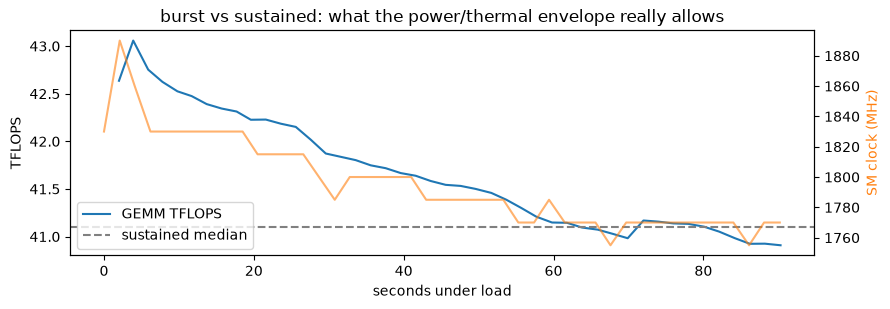

In [4]:
SUSTAINED_S = 90     # >=90 s: laptop clocks need 60-90 s of load to settle; desktops settle in seconds
SUST = pk.probe_sustained_tflops(DEVICE, seconds=SUSTAINED_S)
print(f"burst {SUST['burst_tflops']:.1f} TFLOPS  ->  sustained {SUST['sustained_tflops']:.1f} "
      f"(band {SUST['sustained_min_tflops']:.1f}-{SUST['sustained_max_tflops']:.1f})  [{SUST['dtype']}]")

import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(9, 3.2))
ax1.plot([w['t'] for w in SUST['windows']], [w['tflops'] for w in SUST['windows']], label='GEMM TFLOPS')
ax1.axhline(SUST['sustained_tflops'], ls='--', c='gray', label='sustained median')
ax1.set_xlabel('seconds under load'); ax1.set_ylabel('TFLOPS'); ax1.legend(loc='lower left')
if SUST['clock_trace']:
    ax2 = ax1.twinx()
    ax2.plot([r['t'] for r in SUST['clock_trace']], [r['clock_mhz'] for r in SUST['clock_trace']],
             c='tab:orange', alpha=0.6)
    ax2.set_ylabel('SM clock (MHz)', color='tab:orange')
plt.title('burst vs sustained: what the power/thermal envelope really allows')
plt.tight_layout(); plt.show()

In [5]:
MEMBW  = pk.probe_memory_bandwidth(DEVICE)
LAUNCH = pk.probe_launch_overhead_us(DEVICE)
H2D    = pk.probe_h2d_bandwidth(DEVICE)
CPU    = pk.probe_cpu()
PROBES = {'matmul_tflops': BURST, 'sustained': SUST, 'membw': MEMBW,
          'launch_overhead_us': LAUNCH, 'h2d': H2D, 'cpu': CPU}
_fmt = lambda v, spec='.0f': format(v, spec) if v is not None else 'n/a'   # probes may fall back to None
print(f"memory bandwidth : copy {_fmt(MEMBW['copy_gbps'])} GB/s, triad {_fmt(MEMBW['triad_gbps'])} GB/s")
print(f"launch overhead  : {LAUNCH:.1f} us/kernel  (x ~400 kernels/step = {LAUNCH*400/1000:.1f} ms/step floor)")
if H2D:
    print(f"H2D bandwidth    : pinned {_fmt(H2D['pinned_gbps'], '.1f')} GB/s, pageable "
          f"{_fmt(H2D['pageable_gbps'], '.1f')} GB/s, 1MB latency {_fmt(H2D['small_1mb_ms'], '.2f')} ms")
print(f"CPU              : python loop {CPU['python_loop_mops']:.0f} Mops single-core, "
      f"torch fp32 {CPU['torch_fp32_gflops']:.0f} GFLOPS ({CPU['torch_threads']} threads)")

memory bandwidth : copy 221 GB/s, triad 227 GB/s
launch overhead  : 4.2 us/kernel  (x ~400 kernels/step = 1.7 ms/step floor)
H2D bandwidth    : pinned 11.9 GB/s, pageable 7.3 GB/s, 1MB latency 0.10 ms
CPU              : python loop 18 Mops single-core, torch fp32 462 GFLOPS (14 threads)


## 3. The workload, characterized — FLOPs are *counted*, never assumed

`FlopCounterMode` measures what actually dispatches, forward **and** backward.  That matters here:
the 32×32 stem surgery (3×3 stride-1 conv, no maxpool) keeps every residual stage at high
resolution, making this resnet18 cost **1.11 GFLOP/img forward — ~30× more** than naive scaling of
the stock 224 px model would suggest.  An estimator that guessed from the architecture name would
start 30× wrong before touching any hardware.

The memory fit is measured the same way (two fwd+bwd passes, linear fit `mem(bs) = m0 + a·bs`),
because a config tuned on a 96 GB card can hit the **VRAM cliff** on an 8 GB one — OOM, or a silent
fallback to slow low-workspace cudnn algorithms.  Caveat: BN/ReLU/optimizer/augmentation register
~0 FLOPs but cost real bandwidth and launches — that's exactly why Tier 1 carries memory and launch
terms alongside compute.

In [6]:
import models as M       # ../a1-imagenet32/models.py -- the real architectures under study

MODEL       = 'resnet18'   # any of models.BUILDERS: resnet18 | resnet50 | vit | vit_base
N_TRAIN     = 50_000
N_VAL       = 10_000
BATCH_SIZE  = 512
EPOCHS      = 40
NUM_CLASSES = 100

FLOPS = pk.count_flops_per_image(lambda: M.build(MODEL, num_classes=NUM_CLASSES))
WORK = pk.workload_spec(f'{MODEL}-cifar100', n_train=N_TRAIN, n_val=N_VAL,
                        batch_size=BATCH_SIZE, epochs=EPOCHS, flops=FLOPS)
print(f"{MODEL}: {WORK['params']/1e6:.1f}M params   "
      f"{WORK['fwd_flops_per_img']/1e9:.2f} GFLOP/img fwd, {WORK['train_flops_per_img']/1e9:.2f} trained (fwd+bwd)")
print(f"steps/epoch {WORK['steps_per_epoch']}   total steps {WORK['steps_per_epoch']*EPOCHS:,}   "
      f"total {WORK['total_train_flops']/1e15:.1f} PFLOP")

W0717 06:55:32.450000 27360 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


resnet18: 11.2M params   1.11 GFLOP/img fwd, 3.33 trained (fwd+bwd)
steps/epoch 97   total steps 3,880   total 6.6 PFLOP


In [7]:
def _make_batch(bs):
    return (torch.randn(bs, 3, 32, 32, device=DEVICE),
            torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE))

# fp32 fwd+bwd (no autocast) -> a slightly conservative ceiling on the AMP run's true peak.
MEMFIT = pk.measure_memory_scaling(lambda: M.build(MODEL, num_classes=NUM_CLASSES), _make_batch, DEVICE)
if MEMFIT:
    print(f"VRAM fit: static {MEMFIT['static_bytes']/2**20:.0f} MB + {MEMFIT['bytes_per_img']/2**20:.2f} MB/img")
    fits = MEMFIT['max_batch_estimate'] >= BATCH_SIZE
    print(f"largest batch that should fit: ~{MEMFIT['max_batch_estimate']:,}   "
          f"(requested {BATCH_SIZE}: {'OK' if fits else 'WILL NOT FIT -- reduce the batch'})")
else:
    print('memory-fit probe is CUDA-only; skipped')

VRAM fit: static 1148 MB + 8.77 MB/img
largest batch that should fit: ~682   (requested 512: OK)


## 4. Tier 1 — the analytical roofline (the redesign gate)

$$t_{step} = \max\Big(\underbrace{\tfrac{\text{FLOPs/step}}{\text{MFU} \times \text{TFLOPS}_{sustained}}}_{compute}, \underbrace{\tfrac{\text{bytes/step}}{0.7 \times BW}}_{memory}, \underbrace{K \times t_{launch}}_{launch}\Big)$$

The honest unknown is **MFU** (model-FLOPs utilization — achieved useful FLOPs over probed peak).
This repo's own data shows why it must be a *band*, not a point: the identical resnet18 workload
achieves ~30% MFU on the compute-bound laptop but ~2% on the workstation, where per-step overhead
binds; and on the *same* workstation GPU the CNN hits ~30% while the ViT manages only ~16% — so
MFU is calibrated **per architecture** and never reused across model families.

With the default wide band this tier answers only the question that matters at design time —
**"2 minutes, 2 hours, or 2 days?"** — and that is the factory gate: if even the optimistic edge is
unacceptable, redesign *now*.  It never claims ±10%; only Tier 2 earns that.

In [8]:
N_MODULES = len(list(M.build(MODEL, num_classes=NUM_CLASSES).modules()))
T1 = pk.tier1_estimate(WORK, p_tflops=SUST['sustained_tflops'], membw_gbps=MEMBW['triad_gbps'],
                       launch_us=LAUNCH, n_modules=N_MODULES,
                       act_bytes_per_img=MEMFIT['bytes_per_img'] if MEMFIT else None)
for edge in ('optimistic', 'pessimistic'):
    e = T1[edge]
    print(f"{edge:12s} MFU {e['mfu']:4.0%}: t_step {e['t_step_ms']:7.1f} ms ({e['binding_term']}-bound)"
          f"  ->  total {e['total_human']}")
print(f"floors: launch {T1['floors_ms']['launch']:.1f} ms/step, memory {T1['floors_ms']['memory']:.1f} ms/step")

GATE_HOURS = 4
worst = T1['pessimistic']['total_s']
print('\nfactory gate:', 'PASS -- proceed to calibration' if worst < GATE_HOURS * 3600 else
      f'FAIL -- pessimistic estimate {pk.fmt_duration(worst)} exceeds {GATE_HOURS} h: redesign before training')

optimistic   MFU  40%: t_step   103.7 ms (compute-bound)  ->  total 7.5 min
pessimistic  MFU   5%: t_step   829.5 ms (compute-bound)  ->  total 57.6 min
floors: launch 1.4 ms/step, memory 44.9 ms/step

factory gate: PASS -- proceed to calibration


In [9]:
# Design-time what-if: the same workload on hardware we do NOT have access to, from dense-fp16
# spec estimates (fp32-accumulate -- NOT marketing TOPS).  Replace with probed vectors as the
# results/ database grows; until then these are order-of-magnitude by construction.
TARGETS = {
    'Colab T4 (16 GB)':       dict(p_tflops=40.0,  launch_us=6.0),
    'RTX PRO 6000 Blackwell': dict(p_tflops=220.0, launch_us=10.0),
    'CPU-only laptop (est.)': dict(p_tflops=0.15,  launch_us=2.0),
}
for name, spec in TARGETS.items():
    t = pk.tier1_estimate(WORK, n_modules=N_MODULES, **spec)
    print(f"{name:26s} {t['optimistic']['total_human']:>9s} .. {t['pessimistic']['total_human']}")

Colab T4 (16 GB)             7.7 min .. 59.2 min
RTX PRO 6000 Blackwell       1.7 min .. 11.0 min
CPU-only laptop (est.)        32.7 h .. 10.9 days


## 5. Tier 2 — calibrate on this machine (~2.5 min)

Run the *real* training step — same model, batch, dtype, augmentation, optimizer, flags — and
extrapolate.  Training is almost perfectly repetitive (Habitat's premise), so a correctly measured
`t_step` extrapolates nearly exactly.  "Correctly measured" is the whole game:

1. **Warm up 30 steps** — cudnn autotune, allocator growth, autocast caches.  Epoch 1 of the
   laptop reference ran 27.6 s vs 15.5 s steady: extrapolating cold steps overshoots ~78%.
2. **Thermal soak, adaptive** — at least 90 s of continuous post-warmup load, extended until two
   consecutive 15 s blocks agree within 2% (capped at 180 s).  Skip this on a power-capped laptop
   and you measure boost clocks: an un-soaked check on this machine read t_step ≈ 117 ms vs the
   ~160 ms steady truth (−29% — the exact 2-day-surprise error class).
3. **Time 3 × 30-step windows, spaced apart** — sync only at window edges (per-step sync breaks
   CPU/GPU pipelining), GC frozen so collection pauses can't land inside a window, untimed spacer
   steps between windows so they sample different phases of any throttle oscillation.  Median =
   estimate.  The quoted band is additionally widened by the oscillation the 90 s Tier-0 sustained
   probe observed — a one-minute measurement cannot see a multi-minute throttle cycle by itself.
4. **Time eval separately** — this repo's training loop evaluates the full 10k test set every
   epoch *in fp32* (no autocast), a different regime from the fp16 train step; composing them as
   `epochs × (steps·t_step + t_eval)` is what keeps the total honest.

Data is synthetic (random pixels, identical shapes) so the notebook runs on machines that never
downloaded CIFAR — the augmentation pipeline is shape-static, so `t_step` matches real data within
~2%.  **If you change the training notebook's recipe, change the step below to match** —
calibrating a different recipe predicts a different run.

In [10]:
from gpu_data import GPUImageLoader     # ../a1-cv -- the real GPU-resident augmentation pipeline
import numpy as np
import torch.nn as nn

MEAN, STD = (0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)
t_data0 = time.perf_counter()
xtr = torch.randint(0, 256, (N_TRAIN, 3, 32, 32), dtype=torch.uint8, device=DEVICE)
ytr = torch.randint(0, NUM_CLASSES, (N_TRAIN,), device=DEVICE)
xte = torch.randint(0, 256, (N_VAL, 3, 32, 32), dtype=torch.uint8, device=DEVICE)
yte = torch.randint(0, NUM_CLASSES, (N_VAL,), device=DEVICE)
t_data = time.perf_counter() - t_data0

IS_VIT = MODEL.startswith('vit')
train_loader = GPUImageLoader(xtr, ytr, BATCH_SIZE, MEAN, STD, train=True, erasing=IS_VIT, seed=42)
test_loader  = GPUImageLoader(xte, yte, 512, MEAN, STD, train=False)

# Faithful copy of cifar100_hf_train.ipynb section 4: fp16 AMP + GradScaler + unscale_/clip,
# SGD (CNN) / AdamW+mixup (ViT).  scheduler.step() is per-epoch and negligible -- omitted.
model = M.build(MODEL, num_classes=NUM_CLASSES).to(DEVICE).train()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = (torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05) if IS_VIT else
             torch.optim.SGD(model.parameters(), lr=0.1 * BATCH_SIZE / 256, momentum=0.9,
                             nesterov=True, weight_decay=5e-4))
USE_AMP = DEVICE.type == 'cuda'
scaler = torch.amp.GradScaler(DEVICE.type if DEVICE.type == 'cuda' else 'cpu', enabled=USE_AMP)

_it = iter(train_loader)
def step_fn():
    global _it
    try:
        x, y = next(_it)
    except StopIteration:
        _it = iter(train_loader); x, y = next(_it)
    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(DEVICE.type, enabled=USE_AMP):
        if IS_VIT:
            lam = float(np.random.beta(0.2, 0.2))
            perm = torch.randperm(x.size(0), device=x.device)
            out = model(lam * x + (1 - lam) * x[perm])
            loss = lam * criterion(out, y) + (1 - lam) * criterion(out, y[perm])
        else:
            loss = criterion(model(x), y)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer); scaler.update()

@torch.no_grad()
def eval_fn():                       # faithful copy of evaluate(): fp32 (no autocast), top-5, and
    model.eval()                     # the real per-batch .item() syncs -- they serialize the eval
    c1 = c5 = n = 0                  # loop, so dropping them would understate t_eval
    for x, y in test_loader:
        _, pred = model(x).topk(5, dim=1)
        hits = pred.eq(y.view(-1, 1))
        c1 += hits[:, :1].any(1).sum().item()
        c5 += hits.any(1).sum().item()
        n += y.size(0)
    model.train()

# CPU is ~100x slower per step: shrink the protocol so calibration still finishes in ~2 min.
CAL = dict(warmup_steps=30, soak_seconds=90.0, soak_max_seconds=180.0,
           n_windows=3, window_steps=30, spacer_steps=60)
if DEVICE.type == 'cpu':
    CAL = dict(warmup_steps=2, soak_seconds=10.0, soak_max_seconds=20.0,
               n_windows=2, window_steps=3, spacer_steps=0)
print(f'data built in {t_data:.1f}s; calibrating with {CAL} ...')

data built in 0.0s; calibrating with {'warmup_steps': 30, 'soak_seconds': 90.0, 'soak_max_seconds': 180.0, 'n_windows': 3, 'window_steps': 30, 'spacer_steps': 60} ...


In [11]:
band_hint = (SUST['sustained_min_tflops'] / SUST['sustained_max_tflops']
             if SUST.get('sustained_max_tflops') else None)
t0 = time.perf_counter()
C = pk.tier2_calibrate(step_fn, DEVICE, eval_fn=eval_fn, band_hint_ratio=band_hint, **CAL)
print(f"calibration ran {time.perf_counter()-t0:.0f} s, {C['soak_steps']} real optimizer steps "
      f"(soak {'converged' if C.get('soak_converged') else 'hit the cap -- treat the band as wide'})")
print(f"t_step {C['t_step_s']*1e3:.1f} ms  (band {C['t_step_min_s']*1e3:.1f}-{C['t_step_max_s']*1e3:.1f} ms, "
      f"+/-{(C['t_step_max_s']/C['t_step_s']-1)*100:.0f}%)"
      f"   t_eval {C.get('t_eval_s', 0.0):.2f} s   peak VRAM {C.get('peak_vram_gb', float('nan')):.2f} GB")

# Startup charge = one-time costs steady-state extrapolation misses: the warmup surplus actually
# measured just now (autotune etc.) + a data decode/upload allowance (~10 s for HF CIFAR-100).
t_startup = max(0.0, C['warmup_s'] - CAL['warmup_steps'] * C['t_step_s']) + 10.0

PRED = pk.extrapolate_run(WORK, C['t_step_s'], C.get('t_eval_s', 0.0), t_startup)
MFU = pk.implied_mfu(WORK, C['t_step_s'], SUST['sustained_tflops'])
print(f"\nPREDICTED: {PRED['total_human']}   ({PRED['throughput_img_s']:,.0f} img/s, "
      f"epoch {PRED['epoch_s']:.1f} s, MFU {MFU:.0%} of the sustained {SUST['sustained_tflops']:.0f} TFLOPS)")
print(f"Tier 1 bracketed this at {T1['optimistic']['total_human']} .. {T1['pessimistic']['total_human']}; "
      f"calibration collapses the band to the +/-5-15% the hardware allows.")

calibration ran 140 s, 996 real optimizer steps (soak converged)
t_step 121.5 ms  (band 120.8-122.2 ms, +/-1%)   t_eval 1.54 s   peak VRAM 3.57 GB

PREDICTED: 9.2 min   (3,728 img/s, epoch 13.3 s, MFU 34% of the sustained 41 TFLOPS)
Tier 1 bracketed this at 7.5 min .. 57.6 min; calibration collapses the band to the +/-5-15% the hardware allows.


## 6. Validation — prediction vs the runs we actually did

The reference actuals are the sum of the 40 printed per-epoch times from the committed run
notebooks (their timer *includes* the per-epoch eval; startup excluded — so we compare against the
prediction minus its startup charge).  If this machine matches a reference, the error is computed
automatically; if not, saving the record below makes *this* machine a reference for everyone else.

One structural caveat: two biases roughly cancel *on this laptop* — the reference actual counts
epoch 1's autotune surcharge (~+12 s) inside its epoch times while the prediction books it under
startup, and the reference's burst epochs 2–6 (~−11 s vs steady) have no counterpart in a
steady-state `t_step`.  The cancellation is machine-specific luck; on a desktop both terms are
small, on a different laptop they may not offset.

In [12]:
KNOWN_RUNS = [
    dict(gpu_contains='RTX 2000 Ada', power='ac', workload='resnet18-cifar100', bs=512, epochs=40, actual_s=638.4),
    dict(gpu_contains='RTX PRO 6000', power='ac', workload='resnet18-cifar100', bs=512, epochs=40, actual_s=123.5),
    dict(gpu_contains='RTX PRO 6000', power='ac', workload='vit-cifar100',      bs=512, epochs=40, actual_s=165.0),
]
ACTUAL = None
for k in KNOWN_RUNS:
    if (k['gpu_contains'] in (FP.get('gpu') or '') and k['power'] == pk.power_state_tag(FP)
            and k['workload'] == WORK['name'] and k['bs'] == BATCH_SIZE and k['epochs'] == EPOCHS):
        ACTUAL = k['actual_s']

if ACTUAL:
    predicted_epochs_only = PRED['total_s'] - t_startup
    err = (predicted_epochs_only - ACTUAL) / ACTUAL
    print(f"predicted {pk.fmt_duration(predicted_epochs_only)} (epochs only)  vs  "
          f"actual {pk.fmt_duration(ACTUAL)}  ->  error {err:+.1%}")
    print('within the honest band' if abs(err) <= 0.15 else
          'OUTSIDE +/-15% -- check power state, background GPU load, and backend flags')
else:
    print('no matching reference run for this machine/workload -- this run becomes a reference once saved')

predicted 8.9 min (epochs only)  vs  actual 10.6 min  ->  error -16.5%
OUTSIDE +/-15% -- check power state, background GPU load, and backend flags


## 7. Persist to the shared database

One JSON file per record (machines never merge-conflict).  Commit `results/*.json`: each record
carries the fingerprint, probe vector, calibrated `t_step`/MFU, the prediction, and — once the real
run finishes — the actual, which is how the factory's estimates compound across machines.

In [13]:
REC = pk.make_record(FP, PROBES, WORK, C, {**PRED, 'mfu': MFU, 't_startup_s': t_startup},
                     actual_total_s=ACTUAL,
                     notes='synthetic-data calibration; step recipe = cifar100_hf_train.ipynb section 4')
path = pk.save_record(REC)
print('saved', os.path.relpath(path), '\n')

hdr = f"{'machine':34s} {'power':5s} {'workload':20s} {'t_step':>9s} {'MFU':>5s} {'predicted':>10s} {'actual':>9s}"
print(hdr); print('-' * len(hdr))
for r in pk.load_records():
    f, c, p = r['fingerprint'], r.get('calibration') or {}, r.get('prediction') or {}
    sust = ((r.get('probes') or {}).get('sustained') or {}).get('sustained_tflops')
    mfu = (r['workload']['flops_per_step'] / c['t_step_s'] / (sust * 1e12)
           if c.get('t_step_s') and sust else None)
    print(f"{(f.get('gpu') or f['device_type'])[:33]:34s} {pk.power_state_tag(f):5s} "
          f"{r['workload']['name'][:19]:20s} "
          f"{c.get('t_step_s', float('nan'))*1e3:7.1f}ms {('' if mfu is None else format(mfu, '4.0%')):>5s} "
          f"{p.get('total_human', '-'):>10s} "
          f"{pk.fmt_duration(r['actual_total_s']) if r.get('actual_total_s') else '-':>9s}")

saved results\Mushu_NVIDIA-RTX-2000-Ada-Generation-Laptop-GPU_ac_20260717T135805.json 

machine                            power workload                t_step   MFU  predicted    actual
--------------------------------------------------------------------------------------------------
NVIDIA RTX 2000 Ada Generation La  ac    resnet18-cifar100      121.5ms   34%    9.2 min  10.6 min


## 8. Cross-machine transfer — and why naive scaling fails

To predict machine B from a calibration on machine A: keep A's **per-architecture MFU** for the
compute term, take the launch/memory floors from **B's own probes**, and re-run the roofline
`max()`.  When the binding term is no longer compute on B, the transfer is flagged low-confidence —
that's the signal to spend 2.5 minutes calibrating on B directly.

The failure this prevents: scaling this laptop's 10.6 min by the *marketing* TFLOPS ratio predicts
the workstation run at ~10 seconds — off by >10× — because at 32×32 the workstation's per-step
overhead binds long before its tensor cores do.  The roofline with measured floors lands within
~15% instead.

In [14]:
P_WORKSTATION = 220.0   # dense fp16 (fp32-accumulate) spec estimate; replace with its probed
                        # number once the estimator has run there
XFER = pk.transfer_estimate(WORK, MFU, p_tflops_target=P_WORKSTATION, launch_us_target=10.0,
                            kernels_per_step=T1['assumptions']['kernels_per_step'])
_x = {e: XFER[e]['total_s'] - XFER['assumptions']['startup_s'] for e in ('optimistic', 'pessimistic')}
print(f"transferred estimate (epochs only, startup excluded to match the reference): "
      f"{pk.fmt_duration(_x['optimistic'])} .. {pk.fmt_duration(_x['pessimistic'])}   [{XFER['confidence']}]")
print(f"actual committed workstation run:         {pk.fmt_duration(123.5)}")
naive = PRED['total_s'] * SUST['sustained_tflops'] / 4000.0
print(f"naive marketing-TFLOPS scaling says:      {pk.fmt_duration(naive)}  <- the 2-day-surprise generator")

transferred estimate (epochs only, startup excluded to match the reference): 82 s .. 1.8 min   [medium -- compute-bound transfer, expect ~10-20% error]
actual committed workstation run:         2.1 min
naive marketing-TFLOPS scaling says:      6 s  <- the 2-day-surprise generator


## 9. Critical path — what parallelizes, what cannot

**Strictly serial:** the optimizer chain.  Step *t+1* needs the weights from step *t*, so this
workload's 3,880 steps form a chain no scheduler can shorten — only faster steps (hardware, dtype,
kernel efficiency) or fewer steps (bigger batch) help, and bigger batch was *measured slower* here
(bs1024/2048 < bs512 on the workstation) besides changing optimization dynamics.

**Embarrassingly parallel:** everything between runs.  DataParallel across two RTX PRO 6000s
measured **~1.0×** on this model scale — per-step all-reduce plus Python driving overhead cancels
the split compute at 32×32 — so the workstation's honest capacity is *two concurrent experiments*,
not one experiment at 2×.  Model it as `speedup(n) = n / (1 + n·t_overhead/t_compute)` and revisit
only when a single step's compute exceeds ~50 ms.  Hyperparameter sweeps bin-pack onto (machine,
GPU) slots using Tier-1 estimates; data prep overlaps a previous run's training; eval can run
against checkpoints on another card, off the critical path.

**Amdahl framing for the factory:** for this repo, data prep is ~10–20 s and eval ~3–6% of each
epoch, so training is >95% of the pipeline's critical path — which is precisely why the Tier-1
gate must run *before* the chain starts.  The minimum latency of any configuration is one full
training chain; the factory's only two levers on it are step speed and running more chains at once.

## 10. What does a run cost?

In [15]:
USD_PER_KWH = 0.15
watts = [r['power_w'] for r in C.get('clock_trace', []) if r.get('power_w')]
if watts:
    kwh = statistics.mean(watts) / 1000 * PRED['total_s'] / 3600
    print(f"local energy: ~{statistics.mean(watts):.0f} W avg x {PRED['total_human']} = "
          f"{kwh*1000:.1f} Wh  (~${kwh*USD_PER_KWH:.4f} at ${USD_PER_KWH}/kWh)")
else:
    print('no GPU power telemetry on this machine -- energy cost unavailable')

# Cloud: cost = predicted time on THAT hardware x its rate.  Use a DB record (best) or the Tier-1
# what-if for the target; rates below are editable placeholders -- they drift monthly.
CLOUD_RATES_USD_HR = {'Colab T4': 0.0, 'A100 40GB on-demand': 3.0, 'H100 on-demand': 6.0}
t4 = pk.tier1_estimate(WORK, p_tflops=40.0, launch_us=6.0, n_modules=N_MODULES)
lo, hi = t4['optimistic']['total_s'], t4['pessimistic']['total_s']
print(f"e.g. Colab T4 Tier-1 estimate {pk.fmt_duration(lo)}..{pk.fmt_duration(hi)} -> free tier: $0, "
      f"but budget the wall-clock")

local energy: ~72 W avg x 9.2 min = 11.0 Wh  (~$0.0016 at $0.15/kWh)
e.g. Colab T4 Tier-1 estimate 7.7 min..59.2 min -> free tier: $0, but budget the wall-clock


## 11. Limitations and where this goes next

- **Tier 1's band is wide by design** — it's a gate, not a forecast.  It narrows per architecture
  as `results/` accumulates calibrated MFUs (CNN ≠ ViT even on identical hardware: ~30% vs ~16%).
- **Thermal state is the biggest residual** on laptops: ±10–15% even after the soak, because
  throttling oscillates on multi-minute cycles (this laptop: steady epochs 15.1–19.6 s).  Ambient
  temperature, chassis CPU load, and battery/AC all move it — hence the fingerprint.
- **The calibration step must mirror the training recipe.**  If the training notebook adopts the
  optimization findings (bf16 + channels_last, AMP eval), update §5's step to match and recalibrate.
- **torch.compile** (via triton-windows on this box) is the one untested lever — if adopted, add a
  compiled variant to the calibration so its gain is measured, not assumed.
- **Larger-scale datasets** add terms this CIFAR-scale notebook can ignore: disk/decode throughput
  for streaming (probe exists in `perfkit`), DataLoader worker scaling, and H2D per-batch traffic.
- Prior art for context: Paleo (ICLR'17), Habitat (ATC'21, 11.8% mean cross-GPU error), DNNPerf
  (ICSE'23, ~7% with a learned model), PaLM App. B (the MFU definition), and the time-based
  roofline of Wang et al. 2020 — this notebook is deliberately the pragmatic subset of those ideas.